In [13]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords

In [14]:
# Download stopwords
nltk.download('stopwords')

print("Library berhasil diimport")

Library berhasil diimport


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
df = pd.read_csv("/content/Data Sentimen MBG (1).csv")

# LABELING


Distribusi label:
label
0    5629
1     790
Name: count, dtype: int64


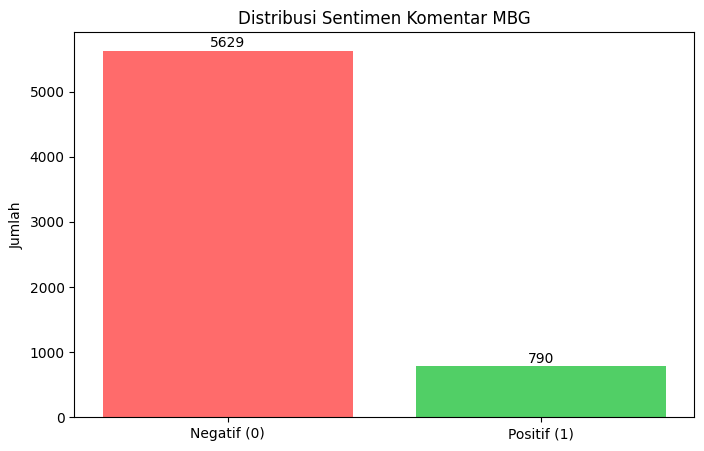

In [17]:
def auto_label(text):
    text = text.lower()

    positif = ['bagus','keren','mantap','baik','hebat','setuju','dukung']
    negatif = ['jelek','buruk','korupsi','maling','rusak','parah']

    if any(word in text for word in positif):
        return 1
    elif any(word in text for word in negatif):
        return 0
    else:
        return 0  # default negatif

df['label'] = df['text'].apply(auto_label)

print("Distribusi label:")
print(df['label'].value_counts())

# Visualisasi distribusi
plt.figure(figsize=(8,5))
counts = df['label'].value_counts()
plt.bar(['Negatif (0)', 'Positif (1)'], counts.values, color=['#ff6b6b', '#51cf66'])
plt.title('Distribusi Sentimen Komentar MBG')
plt.ylabel('Jumlah')
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

# CLEANING TEKS

In [18]:
def cleaning(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   # URL
    text = re.sub(r'@\w+', '', text)      # mention
    text = re.sub(r'#\w+', '', text)      # hashtag
    text = re.sub(r'[^a-z\s]', '', text)  # simbol & angka
    return text

df['text_clean'] = df['text'].apply(cleaning)
print("Contoh teks setelah cleaning:")
print(df['text_clean'].iloc[0])

Contoh teks setelah cleaning:
penguasa dan pelaksana program mbg menjadi penguasa naga ke  dari penguasa  naga


# TOKENISASI

In [19]:
df['tokens'] = df['text_clean'].apply(lambda x: x.split())
print("Contoh tokenisasi:")
print(df['tokens'].iloc[0])


Contoh tokenisasi:
['penguasa', 'dan', 'pelaksana', 'program', 'mbg', 'menjadi', 'penguasa', 'naga', 'ke', 'dari', 'penguasa', 'naga']


# BUILD VOCABULARY

In [20]:
vocab = {}
for sentence in df['tokens']:
    for word in sentence:
        if word not in vocab:
            vocab[word] = len(vocab) + 1  # start from 1, 0 for padding

print(f"Vocabulary size: {len(vocab)} unique tokens")
print(f"Contoh vocab: {list(vocab.items())[:20]}")

Vocabulary size: 16377 unique tokens
Contoh vocab: [('penguasa', 1), ('dan', 2), ('pelaksana', 3), ('program', 4), ('mbg', 5), ('menjadi', 6), ('naga', 7), ('ke', 8), ('dari', 9), ('anaknya', 10), ('makan', 11), ('x', 12), ('bapaknya', 13), ('penganguran', 14), ('rusak', 15), ('lah', 16), ('negara', 17), ('kalau', 18), ('nepotisme', 19), ('korupsi', 20)]


# STOPWORD REMOVAL

In [21]:
stop_words = set(stopwords.words('indonesian'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

print(f"Setelah stopword removal:")
print(f"Contoh tokens: {df['tokens'].iloc[0]}")

Setelah stopword removal:
Contoh tokens: ['penguasa', 'pelaksana', 'program', 'mbg', 'penguasa', 'naga', 'penguasa', 'naga']


# NORMALIZATION

In [22]:
normal_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "bgt": "banget",
    "yg": "yang"
}

def normalize(words):
    return [normal_dict.get(word, word) for word in words]

df['tokens'] = df['tokens'].apply(normalize)
print(f"Setelah normalisasi:")
print(f"Contoh tokens: {df['tokens'].iloc[0]}")

Setelah normalisasi:
Contoh tokens: ['penguasa', 'pelaksana', 'program', 'mbg', 'penguasa', 'naga', 'penguasa', 'naga']


# ENCODING DAN PADDING

In [23]:
def encode(sentence):
    return [vocab[word] for word in sentence]

df['encoded'] = df['tokens'].apply(encode)

max_len = 30  # panjang maksimum sequence

def pad(seq):
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

df['padded'] = df['encoded'].apply(pad)

print(f"Contoh encoded: {df['encoded'].iloc[0]}")
print(f"Contoh padded: {df['padded'].iloc[0]}")

Contoh encoded: [1, 3, 4, 5, 1, 7, 1, 7]
Contoh padded: [1, 3, 4, 5, 1, 7, 1, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# SPLIT DATA

In [24]:
X = torch.tensor(list(df['padded']), dtype=torch.long)
y = torch.tensor(df['label'].values, dtype=torch.long)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split data: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

X shape: torch.Size([6419, 30])
y shape: torch.Size([6419])
Train: 4493 samples
Validation: 963 samples
Test: 963 samples


# CLASS WEIGHTS

In [25]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['label']
)
weights = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights: {weights}")

Class weights: tensor([0.5702, 4.0627])


# DATALOADER

In [26]:
batch_size = 16

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

print(" DataLoader siap")

 DataLoader siap


# MODEL LSTM

In [28]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        out = h_n[-1]
        out = self.dropout(out)
        out = self.fc(out)
        return out
# Inisialisasi model
vocab_size = len(vocab) + 1  # +1 untuk padding index 0
model = LSTMModel(vocab_size=vocab_size, embed_dim=128, hidden_dim=128)

print(f"Model initialized with vocab_size: {vocab_size}")
print(model)

Model initialized with vocab_size: 16378
LSTMModel(
  (embedding): Embedding(16378, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


# TRAINING SETUP

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0005)

print(f"Device: {device}")

Device: cpu


# TRAINING LOOP

In [30]:
num_epochs = 20
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_accs.append(train_correct / train_total)

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f}")
    print(f"  Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")
    print("-" * 50)

print("Training selesai!")

Epoch 1/20
  Train Loss: 0.6812 | Train Acc: 0.8698
  Val Loss: 0.6746 | Val Acc: 0.8629
--------------------------------------------------
Epoch 2/20
  Train Loss: 0.6316 | Train Acc: 0.7785
  Val Loss: 0.6064 | Val Acc: 0.7508
--------------------------------------------------
Epoch 3/20
  Train Loss: 0.5403 | Train Acc: 0.7979
  Val Loss: 0.6186 | Val Acc: 0.8069
--------------------------------------------------
Epoch 4/20
  Train Loss: 0.5325 | Train Acc: 0.8685
  Val Loss: 0.5537 | Val Acc: 0.8858
--------------------------------------------------
Epoch 5/20
  Train Loss: 0.4787 | Train Acc: 0.8887
  Val Loss: 0.5324 | Val Acc: 0.8982
--------------------------------------------------
Epoch 6/20
  Train Loss: 0.4566 | Train Acc: 0.8978
  Val Loss: 0.6806 | Val Acc: 0.6220
--------------------------------------------------
Epoch 7/20
  Train Loss: 0.5544 | Train Acc: 0.6929
  Val Loss: 0.5771 | Val Acc: 0.6054
--------------------------------------------------
Epoch 8/20
  Train L

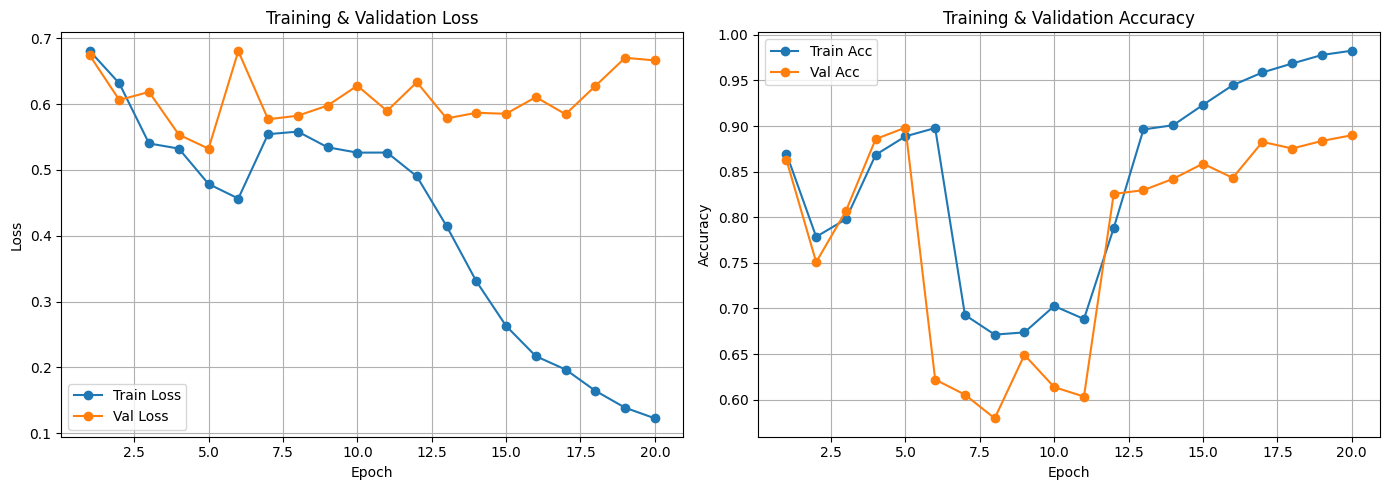

In [31]:
epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs, train_losses, label='Train Loss', marker='o')
ax1.plot(epochs, val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(epochs, train_accs, label='Train Acc', marker='o')
ax2.plot(epochs, val_accs, label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# EVALUASI PADA TEST SET

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.94      0.93      0.94       845
     Positif       0.54      0.57      0.55       118

    accuracy                           0.89       963
   macro avg       0.74      0.75      0.74       963
weighted avg       0.89      0.89      0.89       963



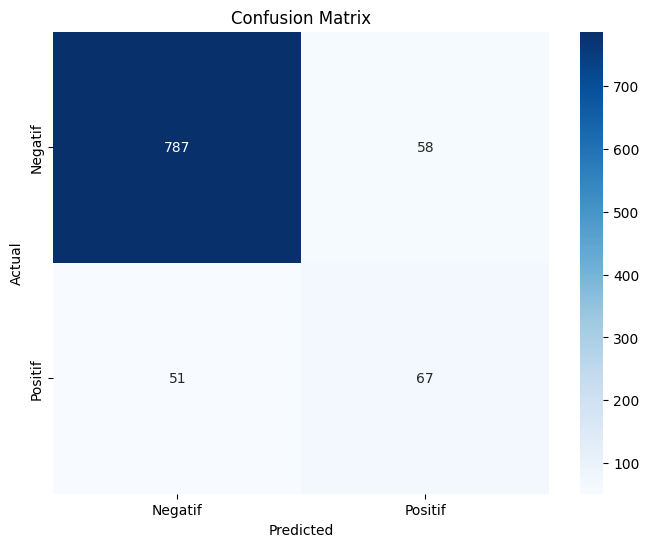

In [32]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negatif', 'Positif']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
def model_summary(model):
    print(f"{'Layer':<20} {'Output Shape':<20} {'Param #':<15}")
    print("="*55)

    total_params = 0
    for name, param in model.named_parameters():
        param_count = param.numel()
        total_params += param_count
        layer_name = name.split('.')[0] if '.' in name else name
        print(f"{layer_name:<20} {str(list(param.shape)):20} {param_count:<15,}")

    print("="*55)
    print(f"{'Total Trainable Params':<40} {total_params:,}")
    return total_params
model = LSTMModel(vocab_size=len(vocab)+1, embed_dim=128, hidden_dim=128)
total_params = model_summary(model)

Layer                Output Shape         Param #        
embedding            [16378, 128]         2,096,384      
lstm                 [512, 128]           65,536         
lstm                 [512, 128]           65,536         
lstm                 [512]                512            
lstm                 [512]                512            
fc                   [2, 128]             256            
fc                   [2]                  2              
Total Trainable Params                   2,228,738
